# Semiconductor Data Analysis

This notebook loads the adjusted-close dataset from `Data/semiconductor_close_analysis.csv` and performs a first round of exploratory analysis for a semiconductor pairs trading project.

In [9]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller


pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

In [10]:
prices = pd.read_csv("Data/semiconductor_close_analysis.csv", index_col="date", parse_dates=True).sort_index()
#prices = pd.read_csv("Data/semiconductor_close_trade.csv", index_col="date", parse_dates=True).sort_index()
categories = pd.read_csv("Data/semiconductor_categories.csv", index_col="ticker")
#categories_tickers = pd.read_csv("categories.csv", index_col="ticker")



df = categories.groupby("category").size().to_frame("count")
all_categories = df.index
core_categories = df.loc[df["count"] > 3].index

prices.index.name = "date"


## Normalized price paths per category

Normalizing each series to 1.0 makes it easier to compare relative movement across semiconductor names.

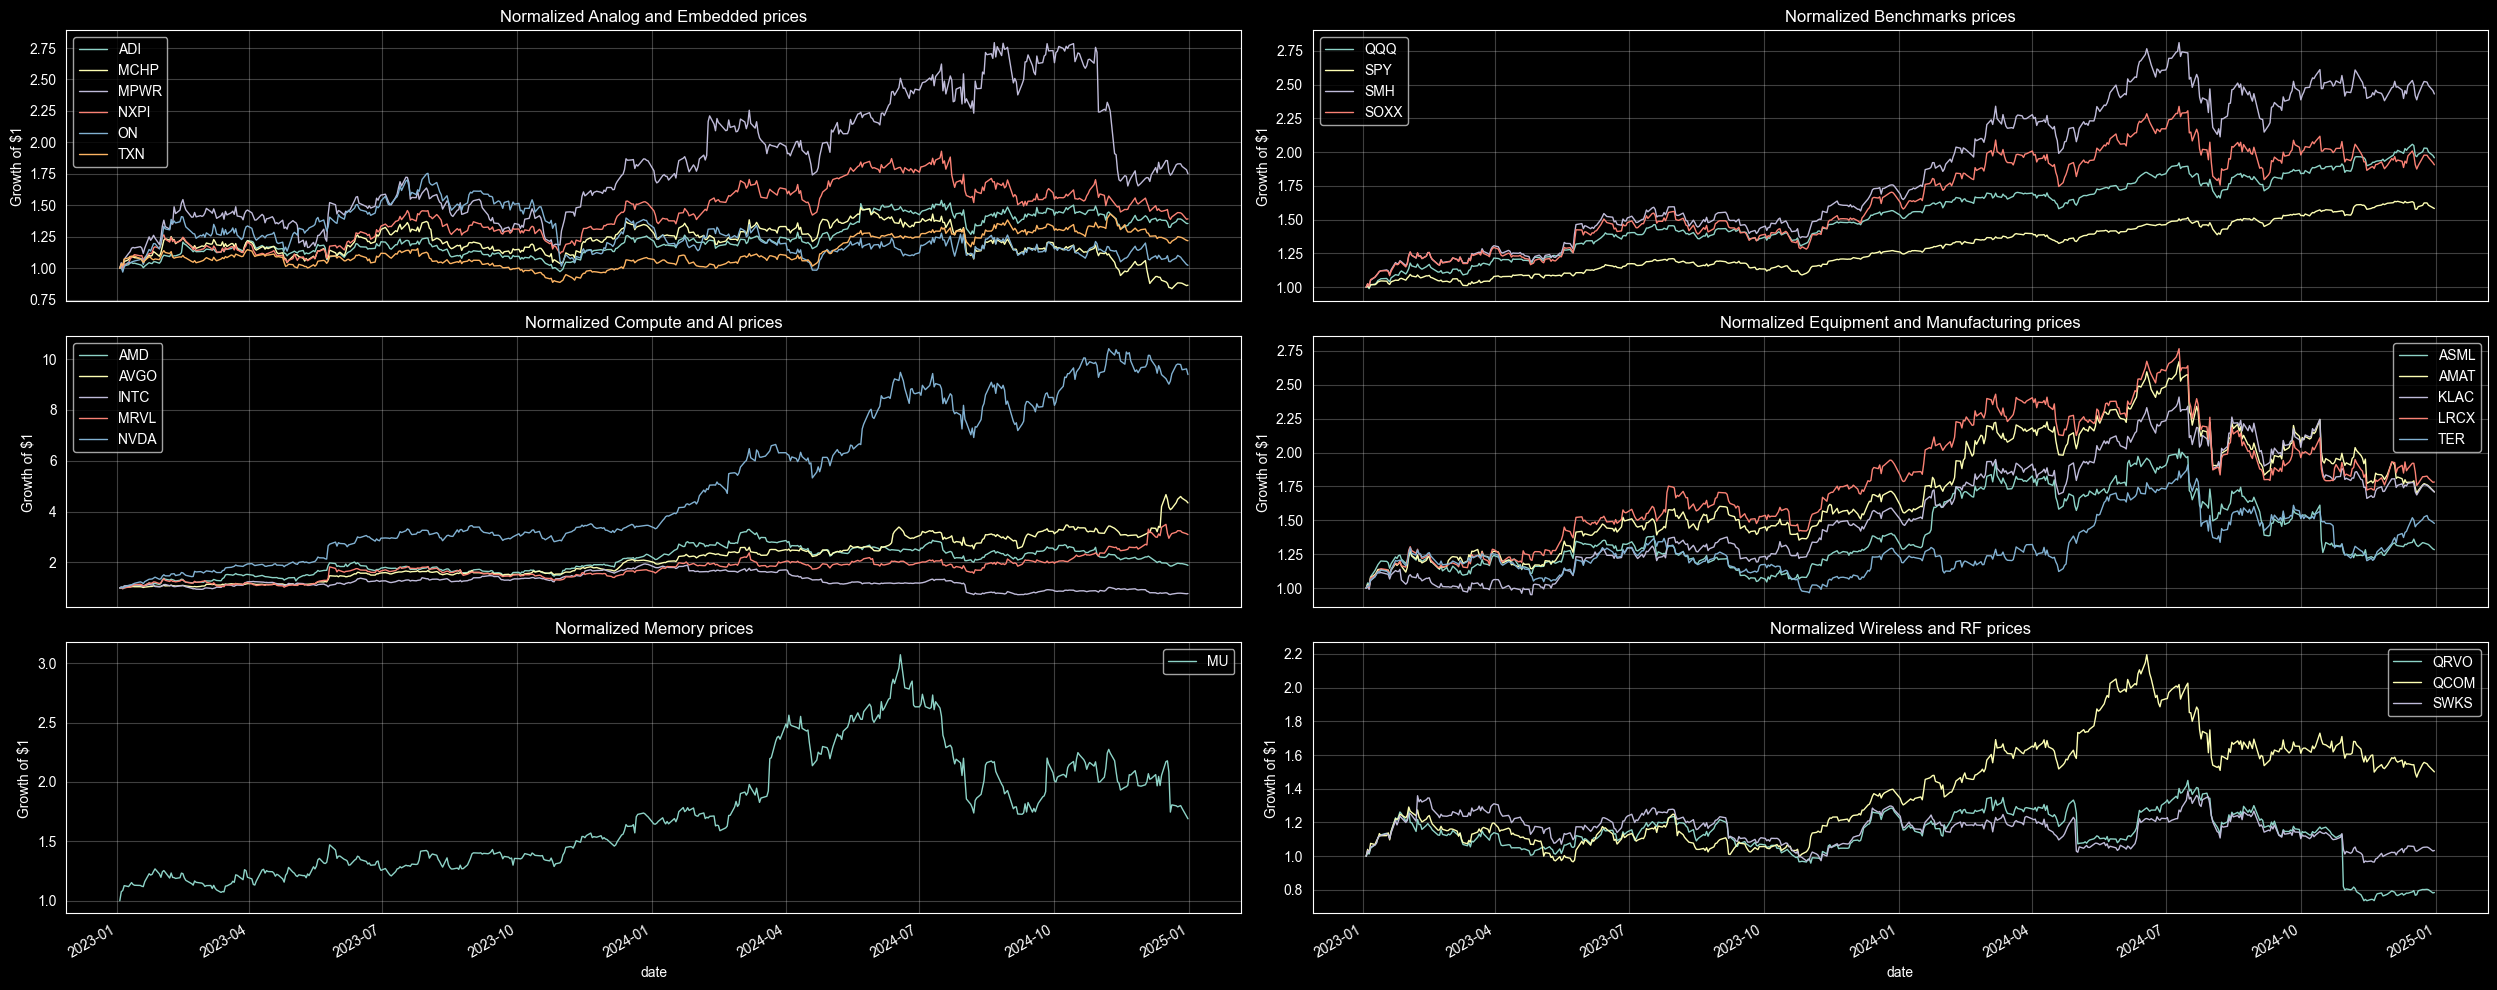

In [11]:
#print(all_categories)
n=len(all_categories)
m=int((n+1)/2)

fig, axes = plt.subplots(m, 2, figsize=(25, 10), sharex=True)
i,j=0,0
for ind in all_categories:
    plot_names=categories.loc[categories["category"] == ind].index
    normalized = prices[plot_names] / prices[plot_names].iloc[0]
    normalized.plot(ax=axes[i,j], linewidth=1)
    axes[i,j].set_title("Normalized " + ind + ' prices')
    axes[i,j].set_ylabel("Growth of $1")
    axes[i,j].grid(alpha=0.25)
    plt.tight_layout()


    if j==0:
        j=1
    else:
        j=0
        i+=1
plt.show()



## Daily returns and correlation structure

In [12]:


returns = prices.pct_change().dropna(how="all")
return_summary = pd.DataFrame(
    {
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "annualized_volatility": returns.std() * np.sqrt(252),
        "category": categories.category,
    }
).sort_values(["category",'mean_daily_return'], ascending=False)

display(return_summary.round(4))

,mean_daily_return,daily_volatility,annualized_volatility,category
QCOM,0.0011,0.0221,0.3503,Wireless and RF
SWKS,0.0003,0.0212,0.3371,Wireless and RF
QRVO,-0.0002,0.0244,0.3873,Wireless and RF
MU,0.0014,0.0281,0.4463,Memory
LRCX,0.0015,0.0250,0.3975,Equipment and Manufacturing
KLAC,0.0014,0.0245,0.3893,Equipment and Manufacturing
AMAT,0.0014,0.0242,0.3843,Equipment and Manufacturing
TER,0.0011,0.0244,0.3872,Equipment and Manufacturing
ASML,0.0008,0.0244,0.3866,Equipment and Manufacturing
NVDA,0.0050,0.0318,0.5049,Compute and AI


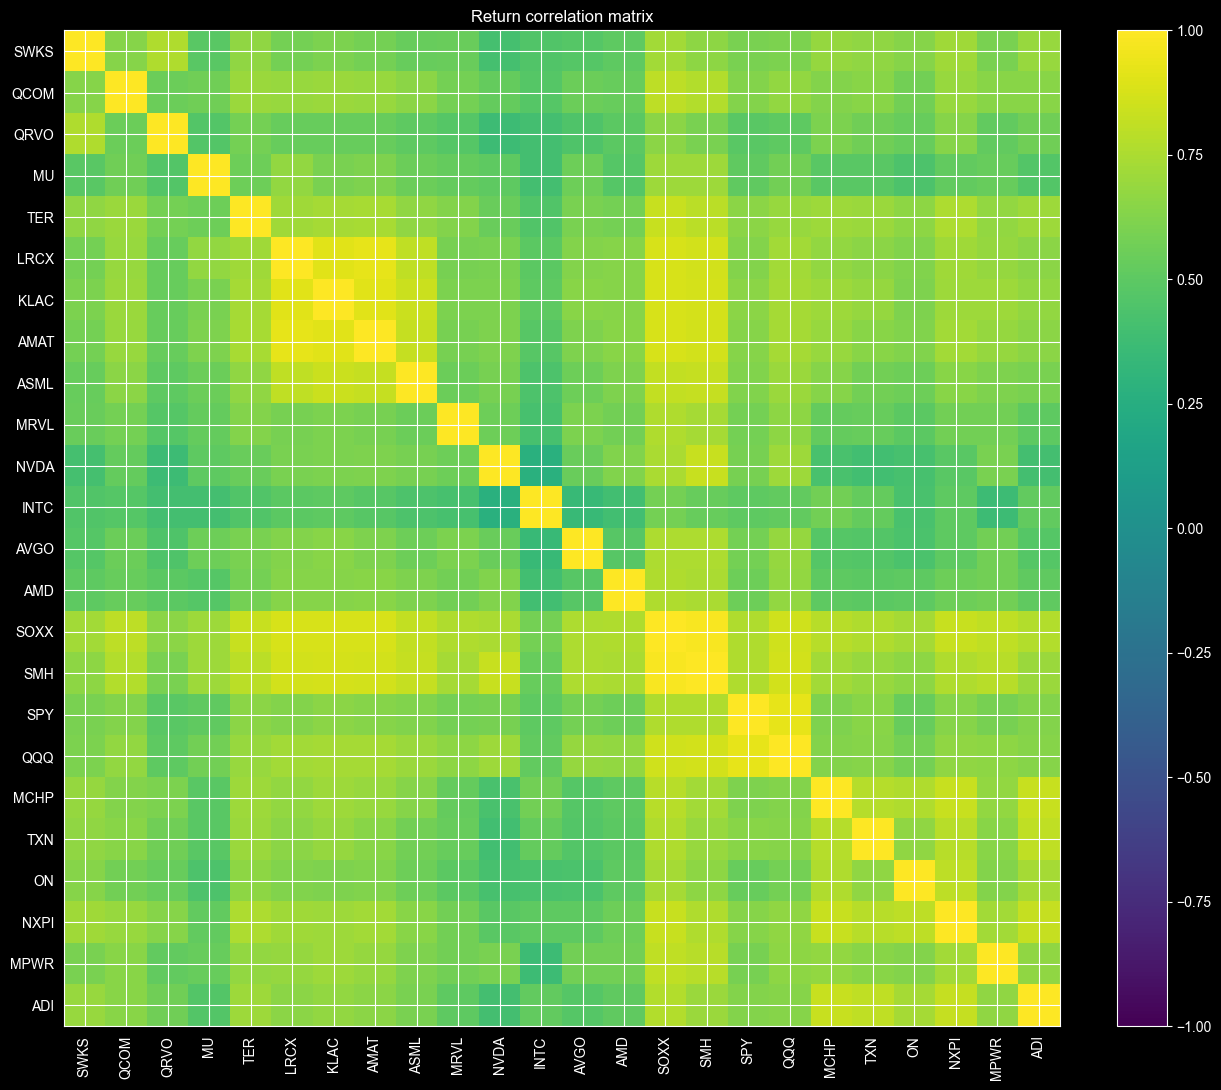

In [13]:
semiconductor_names =categories.sort_values(["category"], ascending=False).index#[ticker for ticker in prices.columns if ticker not in ["SMH", "SOXX", "QQQ", "SPY"]]
correlation_matrix = returns[semiconductor_names].corr()
#display(correlation_matrix)

fig, ax = plt.subplots(figsize=(15, 11))
image = ax.imshow(correlation_matrix, cmap="viridis", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Return correlation matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Most correlated semiconductor pairs

This is a simple first screen for candidate pairs before testing stationarity or spread behavior.

In [14]:
pair_rows = []
for left, right in itertools.combinations(semiconductor_names, 2):
    if categories.loc[left, "category"]!='Benchmarks' and categories.loc[right, "category"] !='Benchmarks':
        pair_rows.append(
            {
            "left": left,
            "right": right,
            "correlation": returns[left].corr(returns[right]),
            "category_left": categories.loc[left, "category"]  ,
            "category_right": categories.loc[right, "category"] ,
            }
        )

top_pairs = pd.DataFrame(pair_rows).sort_values("correlation", ascending=False).reset_index(drop=True)
top_compute_ai = top_pairs.loc[(top_pairs.category_left=='Compute and AI')|( top_pairs.category_right=='Compute and AI')]
display(top_pairs.head(10))
display(top_compute_ai.head(10))

,left,right,correlation,category_left,category_right
0,LRCX,AMAT,0.924750,Equipment and Manufacturing,Equipment and Manufacturing
1,LRCX,KLAC,0.907703,Equipment and Manufacturing,Equipment and Manufacturing
2,KLAC,AMAT,0.906735,Equipment and Manufacturing,Equipment and Manufacturing
3,KLAC,ASML,0.838172,Equipment and Manufacturing,Equipment and Manufacturing
4,MCHP,ADI,0.831414,Analog and Embedded,Analog and Embedded
5,MCHP,NXPI,0.829067,Analog and Embedded,Analog and Embedded
6,NXPI,ADI,0.824482,Analog and Embedded,Analog and Embedded
7,AMAT,ASML,0.822589,Equipment and Manufacturing,Equipment and Manufacturing
8,TXN,ADI,0.809514,Analog and Embedded,Analog and Embedded
9,LRCX,ASML,0.808602,Equipment and Manufacturing,Equipment and Manufacturing


,left,right,correlation,category_left,category_right
62,AMAT,AMD,0.642529,Equipment and Manufacturing,Compute and AI
63,KLAC,AVGO,0.641002,Equipment and Manufacturing,Compute and AI
64,LRCX,AMD,0.639352,Equipment and Manufacturing,Compute and AI
67,KLAC,AMD,0.634390,Equipment and Manufacturing,Compute and AI
72,TER,MRVL,0.626927,Equipment and Manufacturing,Compute and AI
73,LRCX,AVGO,0.625230,Equipment and Manufacturing,Compute and AI
75,NVDA,AMD,0.620407,Compute and AI,Compute and AI
77,AMAT,NVDA,0.616743,Equipment and Manufacturing,Compute and AI
78,ASML,AMD,0.615773,Equipment and Manufacturing,Compute and AI
82,AMAT,AVGO,0.611572,Equipment and Manufacturing,Compute and AI


## Simple spread diagnostic for the top pair

This is not a full cointegration test, but it is a useful first look at whether the example pair of LRCX and AMAT moves together and whether the spread looks mean-reverting.

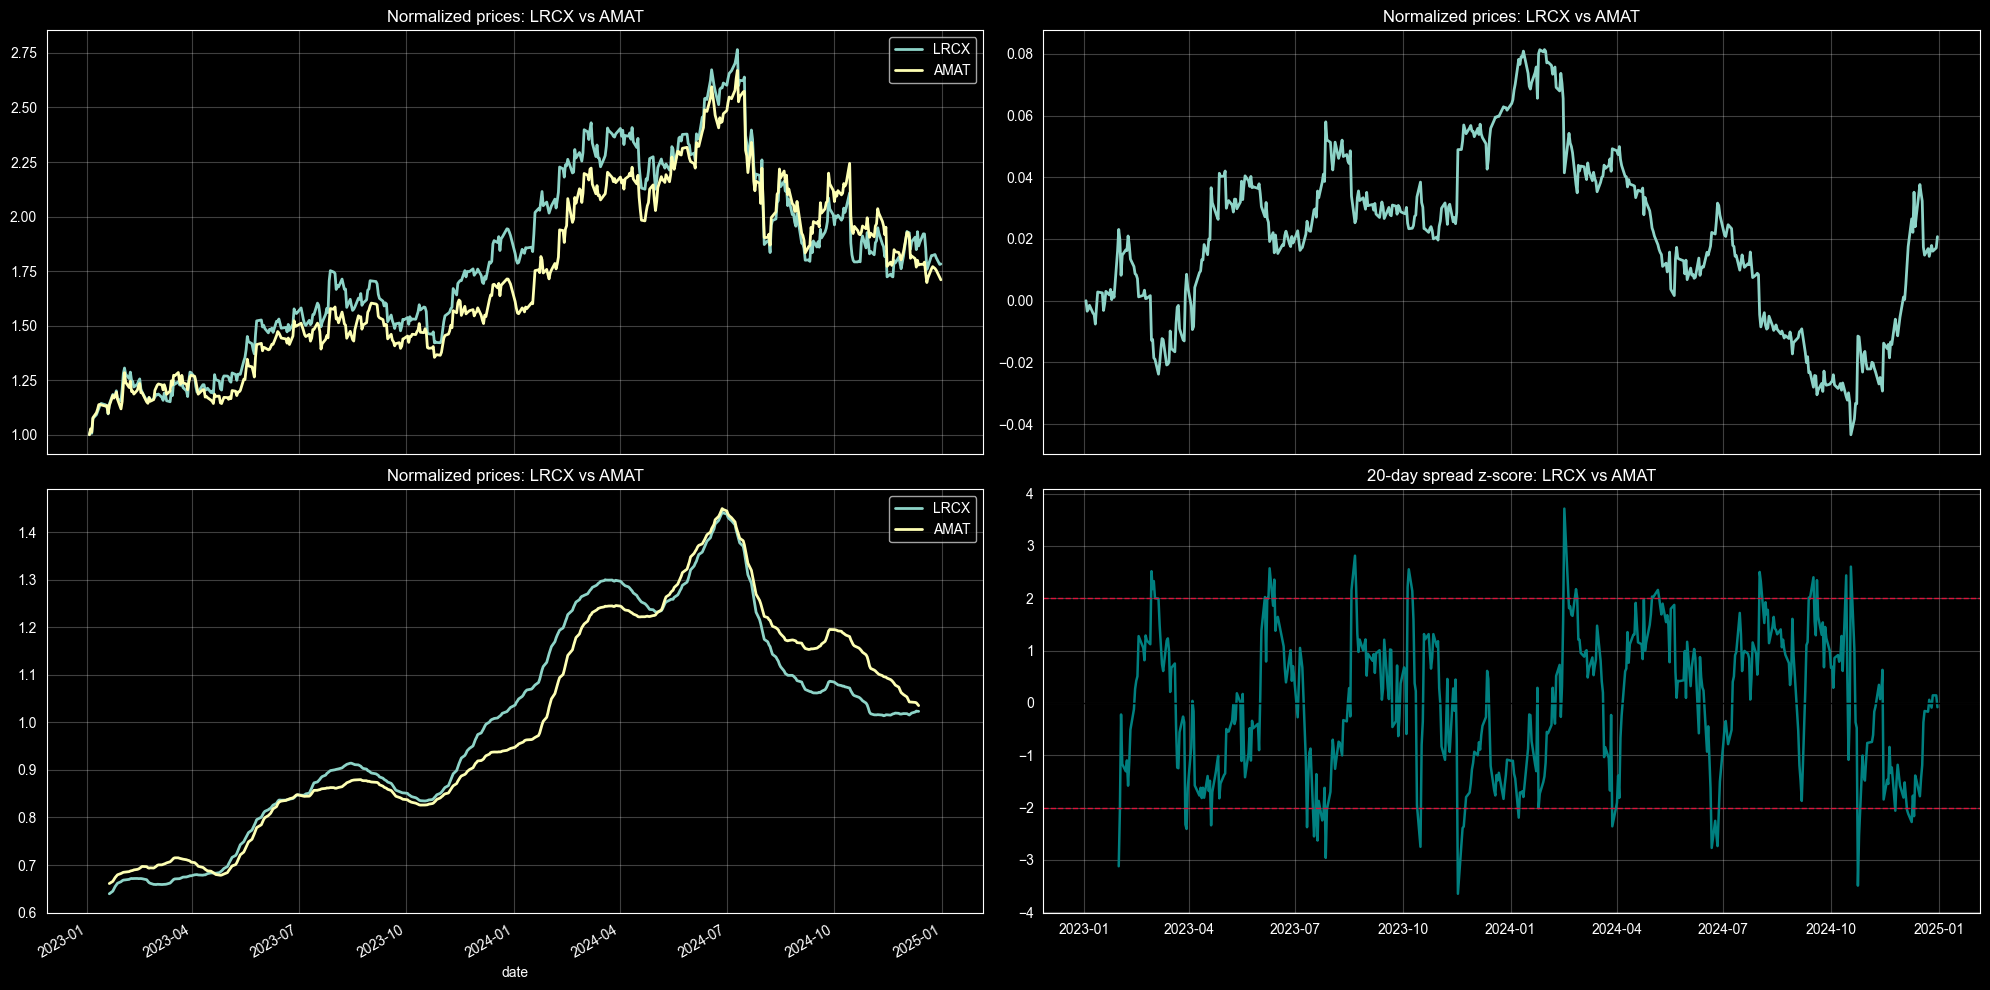

Top pair by return correlation: LRCX-AMAT
Correlation: 0.9248


In [15]:
top_pair = top_pairs.iloc[0]
left_name = 'LRCX' #top_pair["left"]
right_name = 'AMAT' # top_pair["right"]

pair_prices = prices[[left_name, right_name]].dropna().copy()
norm_pair = pair_prices / pair_prices.iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)

(pair_prices / pair_prices.iloc[0]).plot(ax=axes[0,0], linewidth=2)
axes[0,0].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[0,0].grid(alpha=0.25)

((norm_pair.loc[:,left_name]-norm_pair.loc[:,right_name])/(norm_pair.loc[:,left_name]+norm_pair.loc[:,right_name])).plot(ax=axes[0,1], linewidth=2)
axes[0,1].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[0,1].grid(alpha=0.25)

trend =  pair_prices.rolling(window=25, center=True).mean().dropna()
trend2 =  pair_prices.rolling(window=100, center=True).mean().dropna()


(trend / trend.mean()).plot(ax=axes[1,0], linewidth=2)
axes[1,0].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[1,0].grid(alpha=0.25)



#print(pair_prices[left_name])
beta = np.polyfit(pair_prices[left_name], pair_prices[right_name], 1)[0]
spread = pair_prices[right_name] - beta * pair_prices[left_name]
zscore = (spread - spread.rolling(20).mean()) / spread.rolling(20).std()


axes[1,1].plot(spread.index, zscore, color="teal", linewidth=1.8)
axes[1,1].axhline(0, color="black", linewidth=1)
axes[1,1].axhline(2, color="crimson", linestyle="--", linewidth=1)
axes[1,1].axhline(-2, color="crimson", linestyle="--", linewidth=1)
axes[1,1].set_title(f"20-day spread z-score: {left_name} vs {right_name}")
axes[1,1].grid(alpha=0.25)


plt.tight_layout()
plt.show()

print(f"Top pair by return correlation: {left_name}-{right_name}")
print(f"Correlation: {top_pair['correlation']:.4f}")
#print(f"Hedge ratio estimate: {beta:.4f}")

# Dickey-Fuller test

In [16]:
# 0 ADF test statistic
# 1 p-value
# 2 number of lags used
# 3 number of observations used
# 4 critical values dictionary


rows=[]

for left, right in itertools.combinations(semiconductor_names, 2):
    left_series =prices.loc[:,left]
    right_series=prices.loc[:,right]
    series= left_series-right_series*left_series.mean()/right_series.mean()
    result=adfuller(series.dropna())
    number_bench=0
    if categories.loc[left]['category']=='Benchmarks':
        number_bench+=1
    if categories.loc[right]['category']=='Benchmarks':
        number_bench+=1
    rows.append({'left': left, 'right': right, 'p-value': result[1], '# Benchmark': number_bench})
rows=sorted(rows, key=lambda x: x['p-value'])
fuller_results=pd.DataFrame(rows)
display(fuller_results.head(10))







,left,right,p-value,# Benchmark
0,MU,MPWR,0.008771,0
1,MU,KLAC,0.013386,0
2,QRVO,MCHP,0.015142,0
3,TXN,ADI,0.017458,0
4,TER,TXN,0.027619,0
5,MU,AMAT,0.037645,0
6,QCOM,MU,0.040188,0
7,ASML,NXPI,0.040794,0
8,LRCX,AMD,0.045985,0
9,ASML,AMD,0.050672,0
